# Analysis of skills centrality based on final GBN classification
Felix Zaussinger | 29.08.2022 (updated on 01.09.2022 with up-to-date coreness measure)

**Core Analysis Goal(s)**
1. Use updated centrality measures
2. Analyse differences in centrality between GBN occupations
3. Visualise (boxplots, test statistics)

**Key Insight(s)**
1.
2.
3.

In [104]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("notebook")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [105]:
meanprops = {
    "marker": "o",
    "markerfacecolor": "white",
    "markeredgecolor": "black",
    "markersize": "3",
}

Read final classifications

In [139]:
df_sl = pd.read_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists.csv",
    ),
    index_col=0,
)

df_sl_tobi = pd.read_csv(
    os.path.join(
        useful_paths.data_processed,
        "esco",
        "esco_level_gbn_classification_short_lists_tobi.csv",
    ),
    index_col=0,
)

np.all(df_sl_tobi.gbn_classification_short_list == df_sl.gbn_classification_short_list)

False

Read UPDATED skills data (ESCO v1.1) with coreness

In [107]:
from src.data.framework import Esco

esco = Esco()
smd = pd.read_pickle(
    os.path.join(useful_paths.data_processed, "esco", "skills_network_metrics.pkl")
)

cross-sector vs. sector-specific: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=1.577e+03
cross-sector vs. transversal: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.336e-241 Stat=1.100e+03
cross-sector vs. occupation-specific: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:0.000e+00 Stat=5.104e+03


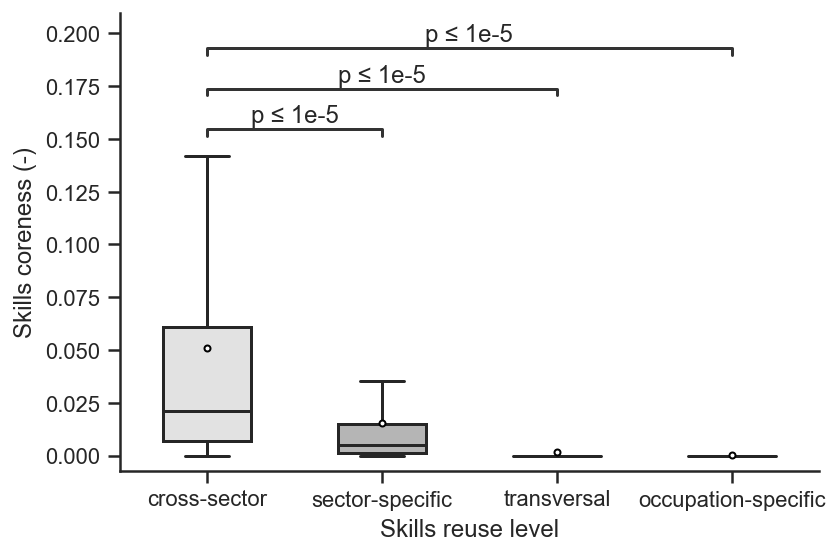

In [108]:
# configure
y = "coreness"
x = "reuseLevel"
df = smd
order = (
    smd.groupby("reuseLevel")
    .mean()
    .sort_values("coreness", ascending=False)
    .index.values
)
pairs = [
    ("cross-sector", "sector-specific"),
    ("cross-sector", "transversal"),
    ("cross-sector", "occupation-specific"),
]

# plot
ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    fliersize=1,
    order=order,
    showmeans=True,
    meanprops=meanprops,
    width=0.5,
    showfliers=False,
    palette="Greys",
)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="simple",
    loc="inside",
    show_test_name=False,
)
annotator.apply_and_annotate()

# label
ax.set_xlabel("Skills reuse level")
ax.set_ylabel("Skills coreness (-)")

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir, "skills_centrality", "coreness_by_reuse_level.png"
    ),
    dpi=300,
)

Missing coreness values
- updated coreness for all skills!

In [109]:
utils.perc_missing(smd)

,missing_obs_abs,missing_obs_rel
conceptType,0.0,0.000000
conceptUri,0.0,0.000000
skillType,1.0,0.000072
reuseLevel,0.0,0.000000
preferredLabel,0.0,0.000000
altLabels,634.0,0.045641
hiddenLabels,13782.0,0.992153
status,0.0,0.000000
modifiedDate,0.0,0.000000
scopeNote,13665.0,0.983730


In [110]:
smd.groupby("skill_classification_esco").count()

,conceptType,conceptUri,skillType,reuseLevel,preferredLabel,altLabels,hiddenLabels,status,modifiedDate,scopeNote,definition,inScheme,description,eigenvector_centrality,betweenness_centrality,betweenness_centrality_norm,mean_centrality,clustering_coefficient,coreness
skill_classification_esco,,,,,,,,,,,,,,,,,,,
brown,477,477,477,477,477,476,0,477,477,5,0,477,477,477,477,477,477,462,477
green,570,570,570,570,570,526,1,570,570,7,0,570,570,570,570,570,570,558,570
neutral,12844,12844,12843,12844,12844,12255,108,12844,12844,214,3,12844,12844,12844,12844,12844,12844,12001,12844


Read occupation-skills matrices

In [111]:
osm_wtd = esco.read_occ_skills_matrix(return_version="weighted", weight_optional=0.5)
osm_uniform = esco.read_occ_skills_matrix(return_version="unweighted")

In [112]:
np.unique(osm_wtd.values.flatten())

array([0. , 0.5, 1. ])

Combine coreness with OSMs

In [113]:
osm = osm_wtd
assert np.all(osm.columns.values == smd.conceptUri.values)

coreness_tiled = np.tile(smd.coreness.values, (3008, 1))
osm_coreness = osm.mul(coreness_tiled)

In [114]:
df_sl_ridx = df_sl.set_index("conceptUri").reindex(index=osm_coreness.index)
(osm.index == df_sl_ridx.index).all()

True

In [115]:
df_slt_ridx = df_sl_tobi.set_index("conceptUri").reindex(index=osm_coreness.index)
(osm.index == df_slt_ridx.index).all()

df_slt_ridx = df_slt_ridx.rename(
    columns={"gbn_classification_short_list": "gbn_classification_short_list_tobi"}
)

Choice of brown list

In [116]:
gbn_clsf = "gbn_classification_short_list_tobi"
df = df_slt_ridx

In [117]:
colsel = ["preferredLabel", gbn_clsf]
osm_merged = pd.concat([osm, df[colsel]], axis=1)

osm_merged_v1 = osm_merged.reset_index().set_index(
    ["conceptUri", "preferredLabel", gbn_clsf]
)
n_ess = (
    osm_merged_v1[osm_merged_v1 == 1]
    .count(axis=1)
    .rename("essential")
    .reset_index()
    .set_index("conceptUri")
)
n_opt = (
    osm_merged_v1[osm_merged_v1 == 0.5]
    .count(axis=1)
    .rename("optional")
    .reset_index()
    .set_index("conceptUri")
)

#### Differences in number of skills

In [118]:
n_skills_by_cat = (
    osm_merged_v1[osm_merged_v1 > 0]
    .count(axis=1)
    .rename("total")
    .reset_index()
    .set_index("conceptUri")
)
n_skills_by_cat["essential"] = n_ess["essential"]
n_skills_by_cat["optional"] = n_opt["optional"]
n_skills_by_cat_long = n_skills_by_cat.melt(
    id_vars=["preferredLabel", gbn_clsf],
    value_vars=["total", "essential", "optional"],
    var_name="skill_type",
    value_name="skills",
)
n_skills_by_cat_long = n_skills_by_cat_long.rename(columns={gbn_clsf: "classification"})

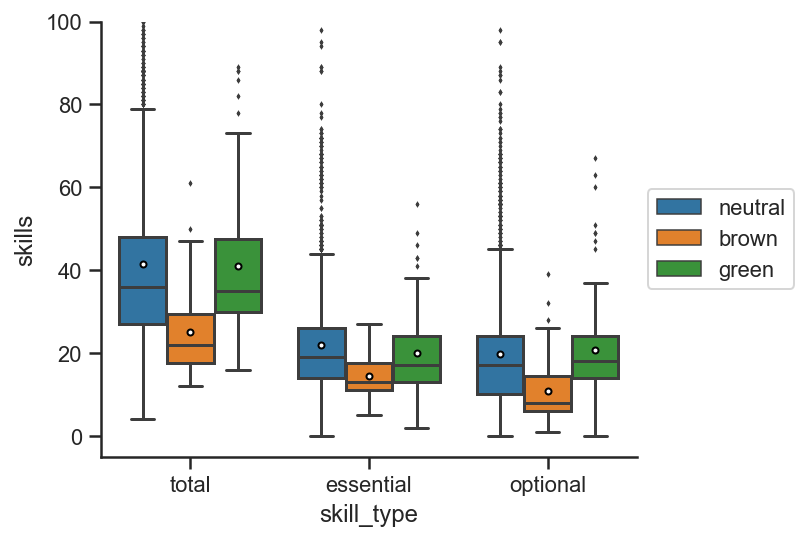

In [119]:
ax = sns.boxplot(
    data=n_skills_by_cat_long,
    x="skill_type",
    y="skills",
    hue="classification",
    fliersize=1,
    showmeans=True,
    meanprops=meanprops,
)

ax.set_ylim(-5, 100)
plotting_utils.move_legend_to_right(ax)
sns.despine()

Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction

essential_brown vs. essential_neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:7.878e-10 Stat=3.779e+01
optional_green vs. optional_brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.191e-09 Stat=3.580e+01
optional_brown vs. optional_neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.203e-07 Stat=2.802e+01
total_green vs. total_brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.035e-10 Stat=4.175e+01
total_brown vs. total_neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.045e-14 Stat=5.849e+01
essential_green vs. essential_brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:9.500e-06 Stat=1.961e+01
optional_green vs. optio

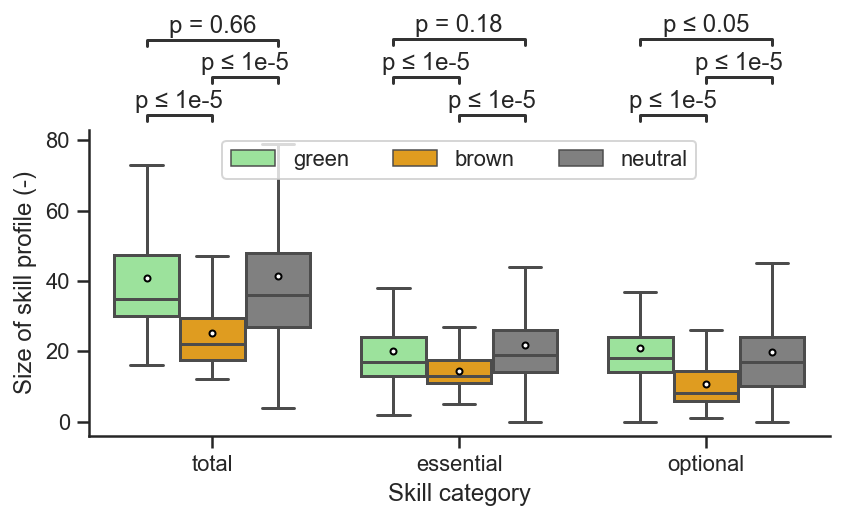

In [120]:
# configure
x = "skill_type"
y = "skills"
hue = "classification"
df_plot = n_skills_by_cat_long
order = ["total", "essential", "optional"]
hue_order = ["green", "brown", "neutral"]
hue_colors = ["lightgreen", "orange", "grey"]

pairs = [
    (("total", "green"), ("total", "brown")),
    (("total", "green"), ("total", "neutral")),
    (("total", "brown"), ("total", "neutral")),
    (("essential", "green"), ("essential", "brown")),
    (("essential", "green"), ("essential", "neutral")),
    (("essential", "brown"), ("essential", "neutral")),
    (("optional", "green"), ("optional", "brown")),
    (("optional", "green"), ("optional", "neutral")),
    (("optional", "brown"), ("optional", "neutral")),
]

# plot
# f, ax = plt.subplots(figsize=(10, 10))
ax = sns.boxplot(
    data=df_plot,
    x=x,
    y=y,
    hue=hue,
    fliersize=1,
    order=order,
    hue_order=hue_order,
    palette=hue_colors,
    showmeans=True,
    meanprops=meanprops,
    width=0.8,
    showfliers=False,
)
plotting_utils.move_legend_to_top(ax, scale=1, ncol=3, upper_anchor=1)
sns.despine()

# test statistic
annotator = Annotator(
    ax, pairs, data=df_plot, x=x, y=y, order=order, hue=hue, hue_order=hue_order
)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="simple",
    loc="outside",
    show_test_name=False,
)
annotator.apply_and_annotate()


# label
ax.set_ylabel("Size of skill profile (-)")
ax.set_xlabel("Skill category")

# save
plt.tight_layout(w_pad=1.2)
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "n_skills_by_{}.png".format(gbn_clsf),
    ),
    dpi=300,
)

In [121]:
import scikit_posthocs as sp

res = []
for skill_type in ["total", "essential", "optional"]:
    skill_type_query = "'" + "{}".format(skill_type) + "'"
    dfm = n_skills_by_cat_long.query("skill_type == {}".format(skill_type_query))

    pvals = (
        sp.posthoc_dunn(
            dfm, val_col="skills", group_col="classification", p_adjust="bonferroni"
        )
        .unstack()
        .rename(skill_type)
    )

    res.append(pvals)

posthoc_dunn = pd.concat(res, axis=1)
posthoc_dunn

total     essential      optional
brown   brown    1.000000e+00  1.000000e+00  1.000000e+00
        green    1.281768e-09  2.564287e-04  1.251460e-07
        neutral  5.687850e-14  2.072323e-09  3.215119e-07
green   brown    1.281768e-09  2.564287e-04  1.251460e-07
        green    1.000000e+00  1.000000e+00  1.000000e+00
        neutral  1.000000e+00  5.491250e-01  1.116588e-01
neutral brown    5.687850e-14  2.072323e-09  3.215119e-07
        green    1.000000e+00  5.491250e-01  1.116588e-01
        neutral  1.000000e+00  1.000000e+00  1.000000e+00

In [122]:
res = []
for skill_type in ["total", "essential", "optional"]:
    skill_type_query = "'" + "{}".format(skill_type) + "'"
    dfm = n_skills_by_cat_long.query("skill_type == {}".format(skill_type_query))

    pvals = (
        sp.posthoc_ttest(
            dfm, val_col="skills", group_col="classification", p_adjust="bonferroni"
        )
        .unstack()
        .rename(skill_type)
    )

    res.append(pvals)

posthoc_ttest = pd.concat(res, axis=1)
posthoc_ttest

total  essential      optional
neutral neutral  1.000000e+00   1.000000  1.000000e+00
        brown    8.436177e-07   0.000004  3.958663e-03
        green    1.000000e+00   0.515888  1.000000e+00
brown   neutral  8.436177e-07   0.000004  3.958663e-03
        brown    1.000000e+00   1.000000  1.000000e+00
        green    4.836536e-09   0.000075  3.833635e-07
green   neutral  1.000000e+00   0.515888  1.000000e+00
        brown    4.836536e-09   0.000075  3.833635e-07
        green    1.000000e+00   1.000000  1.000000e+00

#### Differences in skills centrality

In [123]:
osm_coreness_merged = pd.concat([osm_coreness, df[colsel]], axis=1)

In [124]:
df

,preferredLabel,description,gbn_classification_esco,gbn_classification_esco_ess,gbn_classification_short_list_tobi
conceptUri,,,,,
http://data.europa.eu/esco/occupation/00030d09-2b3a-4efd-87cc-c4ea39d27c34,technical director,Technical directors realise the artistic visio...,neutral,neutral,neutral
http://data.europa.eu/esco/occupation/000e93a3-d956-4e45-aacb-f12c83fedf84,metal drawing machine operator,Metal drawing machine operators set up and ope...,neutral,neutral,neutral
http://data.europa.eu/esco/occupation/0019b951-c699-4191-8208-9822882d150c,precision device inspector,Precision device inspectors make sure precisio...,neutral,neutral,neutral
http://data.europa.eu/esco/occupation/0022f466-426c-41a4-ac96-a235c945cf97,air traffic safety technician,Air traffic safety technicians provide technic...,neutral,neutral,neutral
http://data.europa.eu/esco/occupation/002da35b-7808-43f3-83bf-63596b8b351f,hospitality revenue manager,Hospitality revenue managers maximise revenue ...,neutral,neutral,neutral
...,...,...,...,...,...
http://data.europa.eu/esco/occupation/ff656b3a-65a8-4b4f-b04e-9db12936519b,demographer,Demographers study a variety of parameters rel...,neutral,neutral,neutral
http://data.europa.eu/esco/occupation/ff8d4065-db44-47c7-a4bd-51b3c306ef70,sorter labourer,Sorter labourers sort recyclable materials and...,green,green,green
http://data.europa.eu/esco/occupation/ffa4dd5d-702b-4828-ad85-17ec50db6656,armoured car guard,Armoured car guards ensure the safe transporta...,neutral,neutral,neutral


In [125]:
osm_coreness_merged_v2 = osm_coreness_merged.reset_index().set_index(
    ["conceptUri", "preferredLabel", gbn_clsf]
)

Aggregate by mean or median?
--> distribution very right-skewed, use median

<AxesSubplot:>

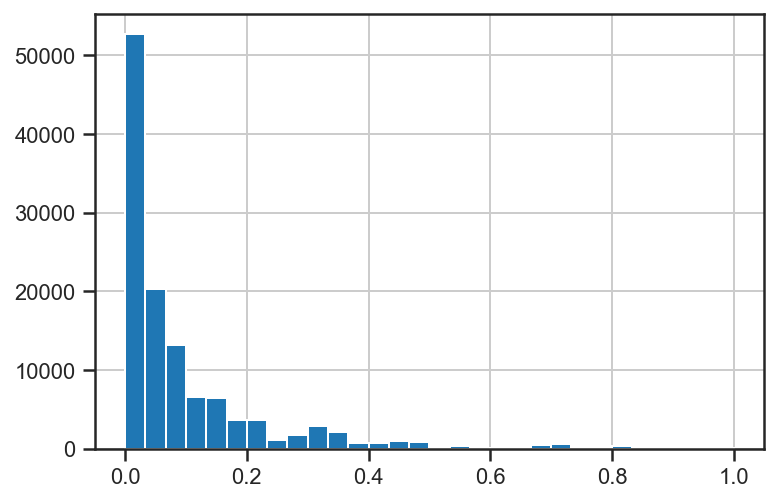

In [126]:
coreness_1d = osm_coreness_merged_v2[osm_coreness_merged_v2 > 0].stack()
coreness_1d.hist(bins=30)

In [127]:
osm_coreness_merged_v2_agg = pd.concat(
    [
        osm_coreness_merged_v2[osm_coreness_merged_v2 > 0]
        .mean(axis=1)
        .rename("coreness_mean"),
        osm_coreness_merged_v2[osm_coreness_merged_v2 > 0]
        .median(axis=1)
        .rename("coreness_median"),
    ],
    axis=1,
)

osm_coreness_merged_v2_agg = osm_coreness_merged_v2_agg.reset_index()
osm_coreness_merged_v2_agg = osm_coreness_merged_v2_agg.rename(
    columns={gbn_clsf: "classification"}
)

Statsannotations: t-test_ind, t-test_welch, t-test_paired, Mann-Whitney, Mann-Whitney-gt, Mann-Whitney-ls, Levene, Wilcoxon, Kruskal

The Shapiro-Wilk test. This test compares our distribution with a normal distribution (like in our plot) and tells us whether our distribution is significantly different from it. Thus, if the test is not significant, the distribution of our data is not significantly different from a normal distribution, or in simple terms: It is normally distributed.

https://bookdown.org/daniel_dauber_io/r4np_book/sources-of-bias.html

array([[<AxesSubplot:title={'center':'coreness_mean'}>,
        <AxesSubplot:title={'center':'coreness_median'}>]], dtype=object)

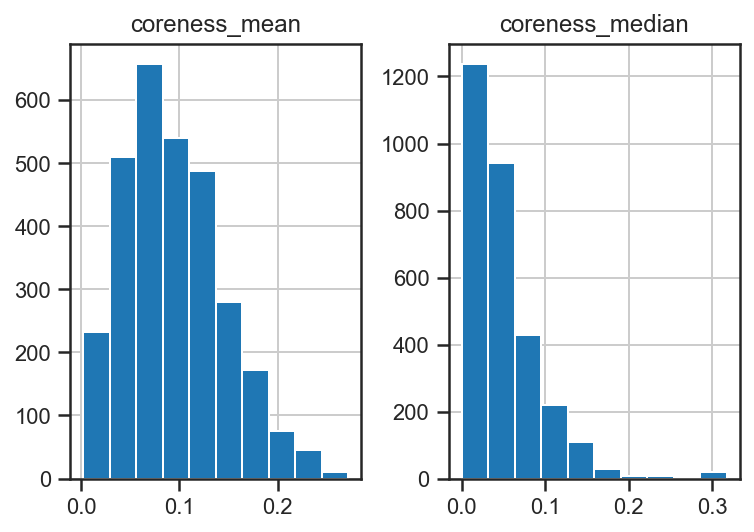

In [128]:
osm_coreness_merged_v2_agg.hist()

In [129]:
print("median: ", stats.shapiro(osm_coreness_merged_v2_agg.coreness_median))
print("mean: ", stats.shapiro(osm_coreness_merged_v2_agg.coreness_mean))

median:  ShapiroResult(statistic=0.8006675243377686, pvalue=0.0)
mean:  ShapiroResult(statistic=0.9723590612411499, pvalue=1.1212752944258394e-23)


Coreness not normally distributed --> use non-parametric tests

green vs. brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.421e-04 Stat=1.282e+01
brown vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:4.390e-01 Stat=5.989e-01
green vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.486e-10 Stat=4.105e+01


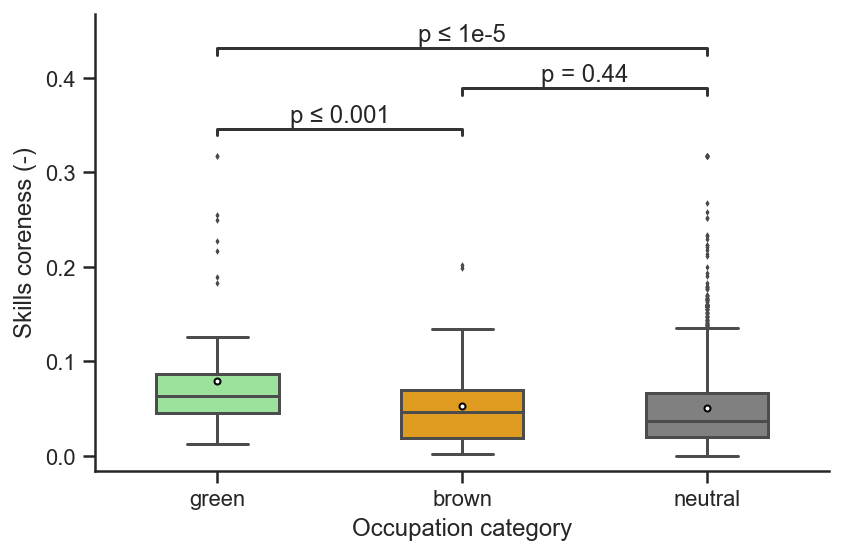

In [130]:
# configure
x = "classification"
y = "coreness_median"
df = osm_coreness_merged_v2_agg
order = ["green", "brown", "neutral"]
pairs = [("green", "brown"), ("green", "neutral"), ("brown", "neutral")]

# plot
ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    fliersize=1,
    order=order,
    palette=["lightgreen", "orange", "grey"],
    showmeans=True,
    meanprops=meanprops,
    width=0.5,
)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="simple",
    loc="inside",
    show_test_name=False,
)
annotator.apply_and_annotate()

# label
ax.set_ylabel("Skills coreness (-)")
ax.set_xlabel("Occupation category")

# save
plt.tight_layout()
plt.savefig(
    os.path.join(
        useful_paths.figure_dir,
        "skills_centrality",
        "median_skills_coreness_by_{}.png".format(gbn_clsf),
    ),
    dpi=300,
)

Cohen's D suggests medium effect size

In [131]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'green'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'brown'").coreness_median,
)

0.4932841884675522

In [132]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'green'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'neutral'").coreness_median,
)

0.6276831806813333

In [133]:
stats_utils.cohen_d(
    x=osm_coreness_merged_v2_agg.query("classification == 'brown'").coreness_median,
    y=osm_coreness_merged_v2_agg.query("classification == 'neutral'").coreness_median,
)

0.05134358327557413

<AxesSubplot:xlabel='coreness_median', ylabel='Count'>

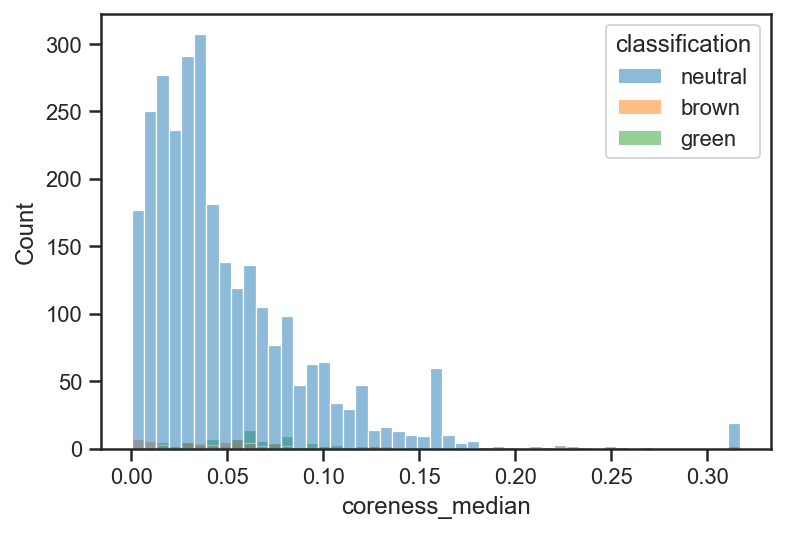

In [134]:
sns.histplot(osm_coreness_merged_v2_agg, x="coreness_median", hue="classification")

green vs. brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:8.470e-01 Stat=3.722e-02
brown vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.240e-03 Stat=9.342e+00
green vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.511e-05 Stat=1.872e+01


(<AxesSubplot:xlabel='classification', ylabel='coreness_mean'>,
  <statannotations.Annotation.Annotation at 0x27e1417dd60>])

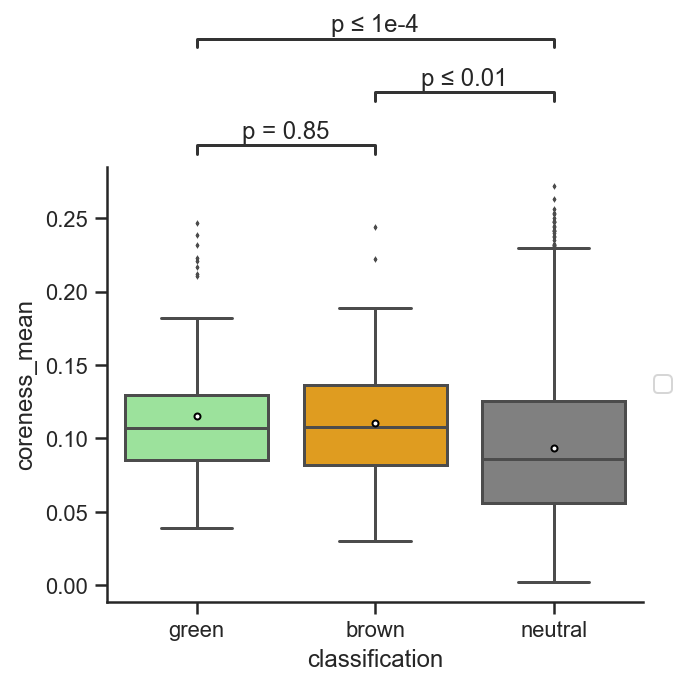

In [135]:
# configure
x = "classification"
y = "coreness_mean"
df = osm_coreness_merged_v2_agg
order = ["green", "brown", "neutral"]
pairs = [("green", "brown"), ("green", "neutral"), ("brown", "neutral")]

# plot
ax = sns.boxplot(
    data=df,
    x=x,
    y=y,
    fliersize=1,
    order=order,
    palette=["lightgreen", "orange", "grey"],
    showmeans=True,
    meanprops=meanprops,
)
plotting_utils.move_legend_to_right(ax)
sns.despine()

# add test statistics
annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
annotator.configure(
    test="Kruskal",
    comparisons_correction="Benjamini-Hochberg",
    text_format="simple",
    loc="outside",
    show_test_name=False,
)
annotator.apply_and_annotate()

In [136]:
smd.columns

Index(['conceptType', 'conceptUri', 'skillType', 'reuseLevel',
       'preferredLabel', 'altLabels', 'hiddenLabels', 'status', 'modifiedDate',
       'scopeNote', 'definition', 'inScheme', 'description',
       'eigenvector_centrality', 'betweenness_centrality',
       'betweenness_centrality_norm', 'mean_centrality',
       'clustering_coefficient', 'coreness', 'skill_classification_esco'],
      dtype='object')

In [137]:
network_metrics = [
    "eigenvector_centrality",
    "betweenness_centrality",
    "betweenness_centrality_norm",
    "mean_centrality",
    "clustering_coefficient",
    "coreness",
    "skill_classification_esco",
]

# configure
x = "skill_classification_esco"
# y = "coreness"
df = smd
order = ["green", "brown", "neutral"]
pairs = [("green", "brown"), ("green", "neutral"), ("brown", "neutral")]

for y in network_metrics:
    # plot
    ax = sns.boxplot(
        data=df,
        x=x,
        y=y,
        fliersize=1,
        order=order,
        palette=["lightgreen", "orange", "grey"],
        showmeans=True,
        meanprops=meanprops,
        showfliers=False,
    )
    plotting_utils.move_legend_to_right(ax)
    sns.despine()

    # add test statistics
    annotator = Annotator(ax, pairs, data=df, x=x, y=y, order=order)
    annotator.configure(
        test="Kruskal",
        comparisons_correction="Benjamini-Hochberg",
        text_format="simple",
        loc="inside",
        show_test_name=False,
    )
    annotator.apply_and_annotate()

    # labelling
    ax.set_ylabel("{} (-)".format(y))
    ax.set_xlabel("Skill classification")

    # save
    plt.tight_layout()
    plt.savefig(
        os.path.join(
            useful_paths.figure_dir,
            "skills_centrality",
            "skills_{}_by_{}.png".format(y, gbn_clsf),
        ),
        dpi=300,
    )
    plt.clf()

green vs. brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.174e-55 Stat=2.470e+02
brown vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.208e-16 Stat=6.860e+01
green vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.932e-50 Stat=2.231e+02
green vs. brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.375e-29 Stat=1.265e+02
brown vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:3.710e-08 Stat=3.030e+01
green vs. neutral: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:1.051e-22 Stat=9.618e+01
green vs. brown: Kruskal-Wallis independent samples (pairwise between groups) with Benjamini-Hochberg correction, P_val:2.

TypeError: Neither the `x` nor `y` variable appears to be numeric.

<Figure size 432x288 with 0 Axes>